In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

:::{admonition} Download
:class: important render-all

This notebook can be downloaded as **{nb-download}`01_head_direction.ipynb`**. See the button at the top right to download as markdown or pdf.
:::


# Head-direction cells: from pynapple to population GLMs

<div class="render-all">

In this tutorial, we compare two recording modalities — extracellular electrophysiology and calcium imaging — using the same 
head-direction system in the mouse as a common reference. Both datasets contain head-direction cells, but the signal properties 
differ: spikes are discrete and fast, while calcium transients are continuous and slow. This gives us a natural testbed 
to see how the same analysis workflow adapts to different data types.

**Part 1 — Extracellular recordings** uses spike trains from the anterodorsal thalamic nucleus (ADn) recorded with a silicon probe ([Peyrache et al., 2015](https://www.nature.com/articles/nn.3968)).

With **pynapple** we will:
1. Load a NWB file and extract spike times and head-direction
2. Compute head-direction tuning curves
3. Compute cross-correlograms during wake and sleep

With **nemos** we will fit a population GLM to characterize functional connectivity:
1. Build spike-history features with a raw history window and with a `RaisedCosineLogConv` basis
2. Fit a single-neuron GLM and compare the two feature representations
3. Fit a `PopulationGLM` to all neurons simultaneously and visualize the coupling filters

**Part 2 — Calcium imaging** uses deconvolved fluorescence traces from head-direction cells in the postsubiculum.

With **pynapple** we will:
1. Load the calcium NWB file and extract transients and head-direction
2. Compute tuning curves and visualize them
3. Decode head-direction from population activity with `nap.decode_template`

With **nemos** we will fit a GLM suited to continuous data:
1. Select significantly tuned neurons with a Rayleigh test
2. Fit a `PopulationGLM` with a Gaussian observation model
3. Re-fit with a feature mask to remove self-coupling and compare the coupling filters

The pynapple documentation can be found [here](https://pynapple.org) and the nemos documentation [here](https://nemos.readthedocs.io/en/latest/).

Let's start by importing all the packages.

</div>

In [2]:
import pynapple as nap
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo
import jax
import workshop_utils
from nemos import _documentation_utils as doc_plots

# LBFGS works better with float64 precision
jax.config.update("jax_enable_x64", True)

# configure pynapple to ignore conversion warning
nap.nap_config.suppress_conversion_warnings = True

# configure some plots
plt.style.use(nmo.styles.plot_style)

## Part 1: Extracellular recordings

### Analyzing head-direction cells with Pynapple

#### Fetch and load data

<div class="render-all">

The dataset comes from [Peyrache et al., 2015](https://www.nature.com/articles/nn.3968). If you ran the workshop setup script the file is already on disk; otherwise `fetch_data` from `workshop_utils` will download it and return the local path.

</div>

In [3]:
path = workshop_utils.fetch_data("Mouse32-140822.nwb")

print(path)

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/data/Mouse32-140822.nwb


<div class="render-all">

Pynapple provides the convenience function `nap.load_file` for loading a NWB file.

**Question:** Can you open the NWB file by passing the variable `path` to the function `load_file` and call the output `data`?

</div>

<div class="render-user">
```{code-cell} ipython3
data =
print(data)
```
</div>

In [4]:
data = nap.load_file(path)

print(data)

Mouse32-140822
┍━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                  │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                 │ TsGroup     │
│ sws                   │ IntervalSet │
│ rem                   │ IntervalSet │
│ position_time_support │ IntervalSet │
│ epochs                │ IntervalSet │
│ ry                    │ Tsd         │
┕━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


<div class="render-all">

The content of the NWB file is not loaded yet. The object `data` behaves like a dictionary.
It contains multiple entries corresponding to different data types stored in the NWB file.
In NWB files, spike times are stored in the `units` entry.

**Question:** Can you load the spike times from the NWB and call the variable `spikes`?

</div>

<div class="render-user">
```{code-cell} ipython3
spikes =   # Get spike timings
print(spikes)
```
</div>

In [5]:
spikes = data["units"]  # Get spike timings
print(spikes)

  Index      rate  location      group
-------  --------  ----------  -------
      0   2.96981  thalamus          1
      1   2.42638  thalamus          1
      2   5.93417  thalamus          1
      3   5.04432  thalamus          1
      4   0.30207  adn               2
      5   0.87042  adn               2
      6   0.36154  adn               2
      7  10.5174   adn               2
      8   2.62475  adn               2
      9   2.55818  adn               2
     10   7.06715  adn               2
     11   0.37911  adn               2
     12   1.58248  adn               2
     13   4.87837  adn               2
     14   8.47337  adn               2
     15   0.23723  adn               3
     16   0.26593  adn               3
     17   6.1304   adn               3
     18  11.0137   adn               3
     19   5.23346  adn               3
     20   6.19514  adn               3
     21   2.85458  adn               3
     22   9.71401  adn               3
     23   1.70552  adn   

<div class="render-all">

The recording contains neurons from several brain areas. We want only those labeled `adn` (anterodorsal nucleus) with a firing rate above 2 Hz.

**Question:** Can you filter `spikes` to keep only ADn neurons above 2 Hz?

Metadata can be accessed as an attribute or like a dictionary key; you can also use the helper methods below:

1. `spikes.location` or `spikes['location']` — returns a pandas Series of brain-area labels.
2. [`spikes.getby_category`](https://pynapple.org/generated/pynapple.TsGroup.getby_category.html#pynapple.TsGroup.getby_category) — filter by a categorical metadata field.
3. [`spikes.getby_threshold`](https://pynapple.org/generated/pynapple.TsGroup.getby_threshold.html#pynapple.TsGroup.getby_threshold) — filter by a numeric threshold.

</div>

<div class="render-user">
```{code-cell} ipython3
spikes =   # Select only ADN neurons with rate > 2.0 Hz
print(len(spikes))
```
</div>

In [6]:
spikes = spikes[(spikes.location=='adn') & (spikes.rate>2.0)]

print(len(spikes))

18


<div class="render-all">

The NWB file contains other information about the recording. `ry` contains the values of the head-direction of the animal over time. 

**Question:** Can you extract the angle of the animal in a variable called `angle` and print it?

</div>

<div class="render-user">
```{code-cell} ipython3
angle =   # Get head-direction data from NWB object
print(angle)
```
</div>

In [7]:
angle = data["ry"]
print(angle)

Time (s)
----------  --------
8812.416    0.581795
8812.4416   0.578113
8812.4672   0.571791
8812.4928   0.554532
8812.5184   0.554532
8812.544    0.554532
8812.5696   0.554532
...
10771.123   5.67668
10771.149   5.67668
10771.174   5.7182
10771.2     5.74727
10771.226   5.74727
10771.251   5.74727
10771.277   5.72318
dtype: float64, shape: (71478,)


<div class="render-all">

The data are not fully loaded into memory yet. While `angle` is a `Tsd` object, its underlying array (accessible via `.d`) is still an `h5py` dataset — pynapple lazy-loads NWB data by default, which is efficient for large recordings that would not fit in RAM.

</div>

In [8]:
print(angle.d)

<HDF5 dataset "data": shape (71478,), type "<f8">


<div class="render-all">

The animal was recorded during wakefulness and sleep. 

**Question:** Can you extract the behavioral intervals in a variable called `epochs`?

</div>

<div class="render-user">
```{code-cell} ipython3
epochs =   # Get behavioral epochs from NWB object
print(epochs)
```
</div>

In [9]:
epochs = data["epochs"]

print(epochs)

  index    start      end  tags
      0      0     8812.3  sleep
      1   8812.3  10771.3  wake
      2  10771.3  22025    sleep
shape: (3, 2), time unit: sec.


/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/.venv/lib/python3.12/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: DataFrame is not sorted by start times. Sorting it.
  data = nap.IntervalSet(df)


<div class="render-all">

NWB files can store intervals with multiple labels. The `IntervalSet` object exposes those labels as metadata.

**Question:** Using the `tags` column, can you split `epochs` into two `IntervalSet` objects — one for `wake` and one for `sleep`?

</div>

<div class="render-user">
```{code-cell} ipython3
wake_ep =  # Get wake intervals from epochs
sleep_ep =  # Get sleep intervals from epochs
```
</div>

In [10]:
wake_ep = epochs[epochs.tags=="wake"]
sleep_ep = epochs[epochs.tags=="sleep"]

#### Compute tuning curves

<div class="render-all">

We now have spikes, a behavioral feature (head-direction), and the epochs during which that feature was recorded. We can compute **tuning curves** — the mean firing rate of each neuron as a function of head-direction during wakefulness — with a single pynapple call.

**Question:** Can you compute the head-direction tuning curves of the ADn units using `nap.compute_tuning_curves` and store the result in `tuning_curves`?

</div>

<div class="render-user">
```{code-cell} ipython3
tuning_curves = nap.compute_tuning_curves(
    data=, # The neural activity as a TsGroup
    features=, # Which feature? Here the head-direction of the animal
    bins=, # How many bins of feature space? Here 61 angular bins is a good numbers
    epochs = angle.time_support, # The epochs should correspond to when the features are defined. Here we use the time support directly
    range= (0, 2*np.pi), # The min and max of the bin array
    feature_names = ["angle"] # Let's give a name to our feature for better labelling of the output.
    ) 
tuning_curves
```
</div>

In [11]:
tuning_curves = nap.compute_tuning_curves(
    data=spikes,
    features=angle, 
    bins=61, 
    epochs = angle.time_support,
    range=(0, 2 * np.pi),
    feature_names = ["angle"]
    )

tuning_curves

<xarray.DataArray (unit: 18, angle: 61)> Size: 9kB
array([[ 5.3160055 ,  8.30492549, 11.86764801, ...,  1.93672712,
         2.15290985,  2.504815  ],
       [ 0.        ,  0.03757885,  0.15823531, ...,  0.53330167,
         0.22081127,  0.        ],
       [ 0.72297675,  0.33820964,  0.09494118, ...,  0.22454807,
         0.38641972,  0.30463966],
       ...,
       [ 0.29769631,  0.37578848,  0.34811768, ...,  0.11227404,
         0.02760141,  0.10154655],
       [ 0.85056088,  0.75157697,  1.07600009, ...,  1.03853483,
         0.93844788,  0.81237243],
       [ 5.27347746,  8.38008318, 10.50682437, ...,  0.95432931,
         1.02125211,  2.23402419]], shape=(18, 61))
Coordinates:
  * unit     (unit) int64 144B 7 8 9 10 13 14 17 18 ... 21 22 24 25 26 29 30 33
  * angle    (angle) float64 488B 0.0515 0.1545 0.2575 ... 6.026 6.129 6.232
Attributes:
    occupancy:  [ 858.  971. 1153. 1392. 1307.  978.  945.  969.  983.  898. ...
    bin_edges:  [array([0.        , 0.10300304, 0.20600608, 0.30900911, 0.412...
    fs:         36.48906175578562
    rates:      [ 8.12564036  0.70295953  2.09866856  8.20425747  3.73227095 ...

<div class="render-all">

The output is an xarray object with neurons along one dimension and angular bins along the other.

</div>

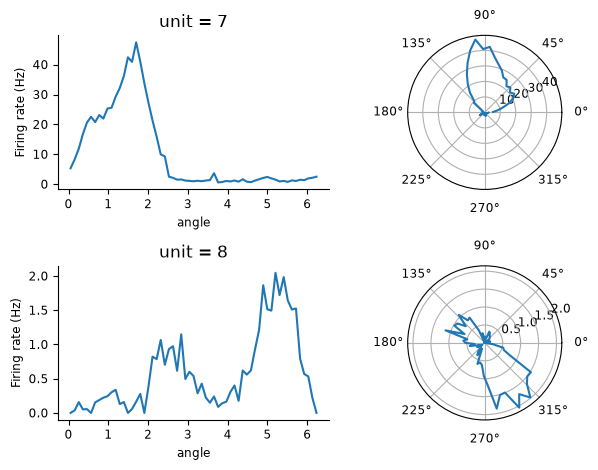

In [12]:
fig = plt.figure()
plt.subplot(221)
tuning_curves[0].plot()
# plt.plot(tuning_curves[0])
plt.ylabel("Firing rate (Hz)")
plt.subplot(222,projection='polar')
plt.plot(tuning_curves.angle, tuning_curves[0].values)
plt.subplot(223)
tuning_curves[1].plot()
plt.ylabel("Firing rate (Hz)")
plt.subplot(224,projection='polar')
plt.plot(tuning_curves.angle, tuning_curves[1].values)
plt.tight_layout()

In [13]:
fig.savefig("../../_static/_check_figs/01-00.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-00.png)
:::
</div>


<div class="render-all">

Most of these neurons are sharply tuned to a preferred direction.

The preferred direction is simply the angle at which firing rate peaks (`idxmax` over the angle dimension).

</div>

In [14]:
pref_ang = tuning_curves.idxmax(dim="angle")

print(pref_ang)

<xarray.DataArray 'angle' (unit: 18)> Size: 144B
array([1.69955012, 5.20165341, 2.21456531, 4.17162303, 0.97852886,
       0.56651671, 4.17162303, 3.45060177, 4.78964126, 0.97852886,
       1.69955012, 3.96561696, 4.58363518, 2.7295805 , 5.20165341,
       3.03858962, 4.27462607, 3.65660784])
Coordinates:
  * unit     (unit) int64 144B 7 8 9 10 13 14 17 18 ... 21 22 24 25 26 29 30 33
Attributes:
    occupancy:  [ 858.  971. 1153. 1392. 1307.  978.  945.  969.  983.  898. ...
    bin_edges:  [array([0.        , 0.10300304, 0.20600608, 0.30900911, 0.412...
    fs:         36.48906175578562
    rates:      [ 8.12564036  0.70295953  2.09866856  8.20425747  3.73227095 ...


<div class="render-all">

The variable `pref_ang` maps each neuron to its preferred direction. Attaching it to the `spikes` object as metadata lets us use it for sorting and labelling later.

**Question:** Can you add `pref_ang` to the metadata of `spikes` under the field name `pref_ang`?

</div>


:::{admonition} Hint
:class: render-all

There are multiple ways of doing this:
```
tsgroup['label'] = metadata
tsgroup.label = metadata
tsgroup.set_info(label=metadata)
```
:::

In [15]:
# spikes['pref_ang'] = pref_ang
spikes.set_info(pref_ang = pref_ang)

spikes

Index    rate      location    group    pref_ang
-------  --------  ----------  -------  ----------
7        10.51737  adn         2        1.7
8        2.62475   adn         2        5.2
9        2.55818   adn         2        2.21
10       7.06715   adn         2        4.17
13       4.87837   adn         2        0.98
14       8.47337   adn         2        0.57
17       6.1304    adn         3        4.17
...      ...       ...         ...      ...
22       9.71401   adn         3        3.97
24       19.65395  adn         3        4.58
25       3.87855   adn         3        2.73
26       4.0242    adn         3        5.2
29       4.23006   adn         4        3.04
30       2.15215   adn         4        4.27
33       5.26316   adn         4        3.66

<div class="render-all">

Let's visualize the spiking activity of each neuron alongside the animal's head-direction, with neurons ordered by their preferred direction. We restrict to a short window for clarity.

</div>

Text(0.5, 0, 'Time (s)')

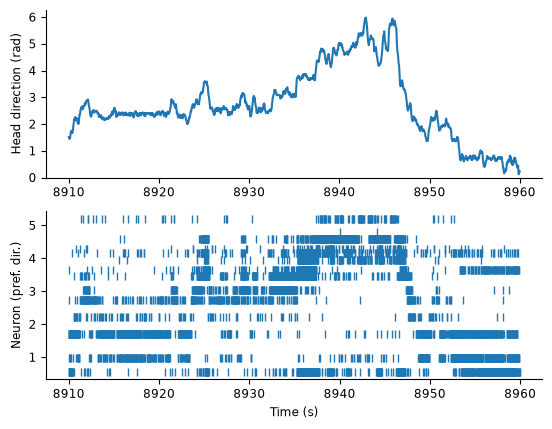

In [16]:
ex_ep = nap.IntervalSet(start=8910, end=8960)

fig = plt.figure()
plt.subplot(211)
plt.ylabel("Head direction (rad)")
plt.plot(angle.restrict(ex_ep))
plt.ylim(0, 2*np.pi)
plt.subplot(212)
plt.plot(spikes.restrict(ex_ep).to_tsd("pref_ang"), '|')
plt.ylabel("Neuron (pref. dir.)")
plt.xlabel("Time (s)")

In [17]:
fig.savefig("../../_static/_check_figs/01-01.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-01.png)
:::
</div>

#### Compute correlograms

<div class="render-all">

The raster shows that some neurons tend to fire together, while others fire at opposite phases. A **cross-correlogram** quantifies this: it measures how often spikes from one neuron occur at each time lag relative to spikes from another, revealing whether pairs are co-active or anti-correlated.

**Question:** Can you compute cross-correlograms during wake for all pairs of neurons using `nap.compute_crosscorrelogram` and call the result `cc_wake`?

</div>

<div class="render-user">
```{code-cell} ipython3
cc_wake = nap.compute_crosscorrelogram(
    group=, # The neural activity as a TsGroup
    binsize=, # I suggest 200 ms bin
    windowsize=, # Let's do a 20 s window
    ep= # Which epoch to restrict the cross-correlograms. Here is it should be wakefulness.
    )
```
</div>

In [18]:
cc_wake = nap.compute_crosscorrelogram(spikes, binsize=0.2, windowsize=20.0, ep=wake_ep)

<div class="render-all">

The output is a pandas DataFrame where each column is a neuron pair, computed automatically for all combinations, and the index gives the time lag. Let's focus on two pairs: neurons 7 and 20 share a preferred direction, while neurons 7 and 26 prefer opposite directions.

Indexing: `cc[(7, 20)]` selects a correlogram column; `tuning_curves.sel(unit=[7, 20])` selects the corresponding tuning curves from the xarray.

</div>

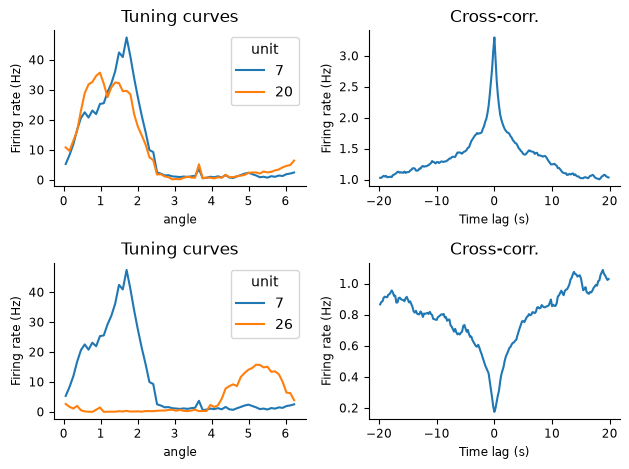

In [19]:
index = spikes.keys()


fig = plt.figure()
plt.subplot(221)
tuning_curves.sel(unit=[7,20]).plot(x='angle', hue='unit')
plt.title("Tuning curves")
plt.ylabel("Firing rate (Hz)")
plt.subplot(222)
plt.plot(cc_wake[(7, 20)])
plt.xlabel("Time lag (s)")
plt.title("Cross-corr.")
plt.ylabel("Firing rate (Hz)")
plt.subplot(223)
tuning_curves.sel(unit=[7,26]).plot(x='angle', hue='unit')
plt.title("Tuning curves")
plt.ylabel("Firing rate (Hz)")
plt.subplot(224)
plt.plot(cc_wake[(7, 26)])
plt.xlabel("Time lag (s)")
plt.title("Cross-corr.")
plt.ylabel("Firing rate (Hz)")
plt.tight_layout()

In [20]:
fig.savefig("../../_static/_check_figs/01-02.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-02.png)
:::
</div>


<div class="render-all">

Neurons with similar preferred directions are positively correlated at lag 0 (they co-fire), while neurons with opposite preferred directions are negatively correlated. The same neurons were also recorded during sleep.

**Question:** Can you compute cross-correlograms during sleep? Use a shorter bin (20 ms) and window (1 s) to match the faster timescales typical of sleep activity.

</div>

<div class="render-user">
```{code-cell} ipython3
cc_sleep = nap.compute_crosscorrelogram(
    group=, # The neural activity as a TsGroup
    binsize=, # I suggest 20 ms bin
    windowsize=, # Let's do a 1 s window
    ep= # Which epoch to restrict the cross-correlograms. Here is it should be sleep.
    )
```
</div>

In [21]:
cc_sleep = nap.compute_crosscorrelogram(spikes, 0.02, 1.0, ep=sleep_ep)

<div class="render-all">

Let's compare the wake and sleep correlograms for the same-direction pair and the opposite-direction pair.

</div>

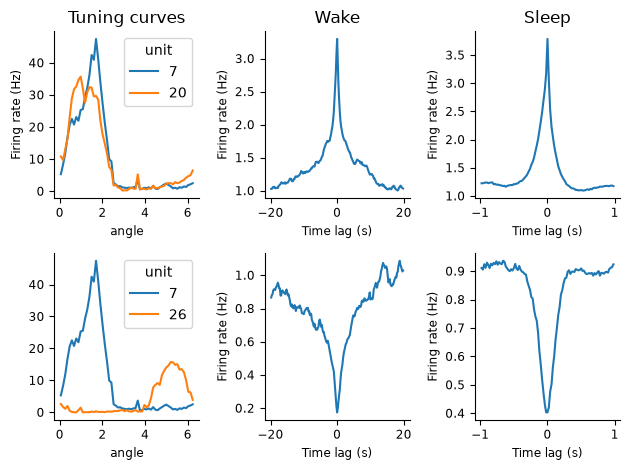

In [22]:
fig = plt.figure()
plt.subplot(231)
tuning_curves.sel(unit=[7,20]).plot(x='angle', hue='unit')
plt.title("Tuning curves")
plt.ylabel("Firing rate (Hz)")
plt.subplot(232)
plt.plot(cc_wake[(7, 20)])
plt.xlabel("Time lag (s)")
plt.ylabel("Firing rate (Hz)")
plt.title("Wake")
plt.subplot(233)
plt.plot(cc_sleep[(7, 20)])
plt.xlabel("Time lag (s)")
plt.ylabel("Firing rate (Hz)")
plt.title("Sleep")
plt.subplot(234)
tuning_curves.sel(unit=[7,26]).plot(x='angle', hue='unit')
plt.subplot(235)
plt.plot(cc_wake[(7, 26)])
plt.xlabel("Time lag (s)")
plt.ylabel("Firing rate (Hz)")
plt.subplot(236)
plt.plot(cc_sleep[(7, 26)])
plt.xlabel("Time lag (s)")
plt.ylabel("Firing rate (Hz)")
plt.tight_layout()

In [23]:
fig.savefig("../../_static/_check_figs/01-03.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-03.png)
:::
</div>

<div class="render-all">

The pairwise relationships are preserved during sleep, even though the animal is not moving and head-direction is undefined. Cells that co-fired during wake continue to do so during sleep, suggesting the coordination is not driven purely by a shared sensory input.

</div>

### Modelling extracellular spike history effects with GLM

<div class="render-all">

The correlograms showed that pairwise coordination is preserved across brain states: co-active pairs during wake remain co-active during sleep, and anti-correlated pairs remain anti-correlated. The goal now is to quantify these functional interactions with a generalized linear model (GLM). Because cells influence each other, the recent spike history of one cell should help predict the activity of another.

</div>

<div class="render-all">

**Question:** Can we predict each neuron's spiking from the recent spike history of the population alone — without using the head-direction signal?

To keep fitting times short we restrict the analysis to the first 3 minutes of the wake epoch.

</div>

In [24]:
# restrict wake epoch to first 3 minutes
wake_ep = nap.IntervalSet(
    start=wake_ep.start[0], end=wake_ep.start[0] + 3 * 60
)

<div class="render-all">
To use the GLM we first need to discretize the spike trains into time bins using pynapple's `count` method.

**Question:** Can you bin the spike trains into 10 ms bins during `wake_ep` and call the result `count`?

</div>

<div class="render-user">
```{code-cell} ipython3
bin_size = 0.01
count =   # Bin spike trains during wake_ep
print(count.shape)
```
</div>

In [25]:
bin_size = 0.01
count = spikes.count(bin_size, ep=wake_ep)

print(count.shape)

(18000, 18)


<div class="render-all">

We sort the neuron columns by preferred direction so that the population activity plots are easier to interpret.

</div>

In [26]:
count = count[:, np.argsort(pref_ang.values)]

<div class="render-all">

Our goal is to estimate pairwise functional interactions: the recent spike history of all neurons is used to predict each neuron's current activity. We start with a single neuron to build intuition before scaling to the full population.

The simplest formulation uses counts in a fixed-length window $y_{t-i}, \dots, y_{t-1}$ to predict the next count $y_t$.

Select neuron 0 from `count` (call it `neuron_count`) and define `epoch_one_spk` as the first 1.2 s of the recording for visualization.

</div>

In [27]:
# select a neuron's spike count time series
neuron_count = count[:, 0]

# restrict to a smaller time interval
epoch_one_spk = nap.IntervalSet(
    start=count.time_support.start[0], end=count.time_support.start[0] + 1.2
)

#### Features Construction

<div class="render-all">

Let's set the spike history window — how far back in time we look to predict the current firing rate.

- Set the window to 800 ms (0.8 s).
- Visualize it with `doc_plots.plot_history_window`.

</div>

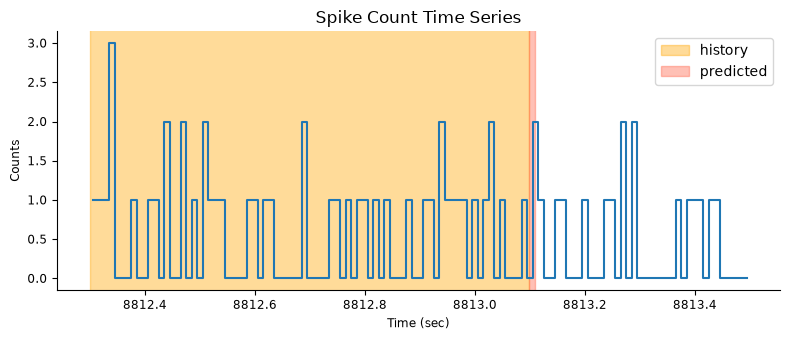

In [28]:
# set the size of the spike history window in seconds
window_size_sec = 0.8

fig = doc_plots.plot_history_window(neuron_count, epoch_one_spk, window_size_sec);

In [29]:
fig.savefig("../../_static/_check_figs/02-01.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-01.png)
:::
</div>

<div class="render-all">

At each time point we slide the window by one bin and stack the spike counts into a matrix. Each row becomes the predictor for the rate in the next bin (the red rectangle in the figure).

</div>

In [30]:
doc_plots.run_animation(neuron_count, epoch_one_spk.start[0])

<div class="render-all">

For time points $t$ smaller than the window size there is no complete history available. Zero-padding would introduce spurious edge artifacts, so instead nemos restricts predictions to $t \geq$ window size and fills earlier entries with NaN.

You can construct this feature matrix with the [`HistoryConv`](https://nemos.readthedocs.io/en/latest/generated/basis/nemos.basis.HistoryConv.html#nemos.basis.HistoryConv) basis.

**Question: Can you:**
    - Convert the window size in number of bins (call it `window_size`)
    - Define an `HistoryConv` basis covering this window size (call it `history_basis`).
    - Create the feature matrix with `history_basis.compute_features` (call it `input_feature`).

</div>

<div class="render-user">
```{code-cell} ipython3
# convert the prediction window to bins (by multiplying with the sampling rate)
window_size = int(window_size_sec * neuron_count.rate)
# define the history bases
history_basis = # Parameter indicate the window size in bins
# create the feature matrix
input_feature =  # Using history_basis compute features on neuron_count
```
</div>

In [31]:
# convert the prediction window to bins (by multiplying with the sampling rate)
window_size = int(window_size_sec * neuron_count.rate)
# define the history bases
history_basis = nmo.basis.HistoryConv(window_size)
# create the feature matrix
input_feature = history_basis.compute_features(neuron_count)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


<div class="render-all">

NeMoS NaN-pads the first `window_size` time points where a full history is not available.
 
</div>

In [32]:
# print the NaN indices along the time axis
print("NaN indices:\n", np.where(np.isnan(input_feature[:, 0]))[0]) 

NaN indices:
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]


<div class="render-all">

Let's verify that the feature matrix dimensions match our expectation.

</div>

In [33]:
print(f"Time bins in counts: {neuron_count.shape[0]}")
print(f"Convolution window size in bins: {window_size}")
print(f"Feature shape: {input_feature.shape}")

Time bins in counts: 18000
Convolution window size in bins: 80
Feature shape: (18000, 80)


<div class="render-all">

Let's visualize the feature matrix over a few time bins to confirm it looks as expected.

</div>

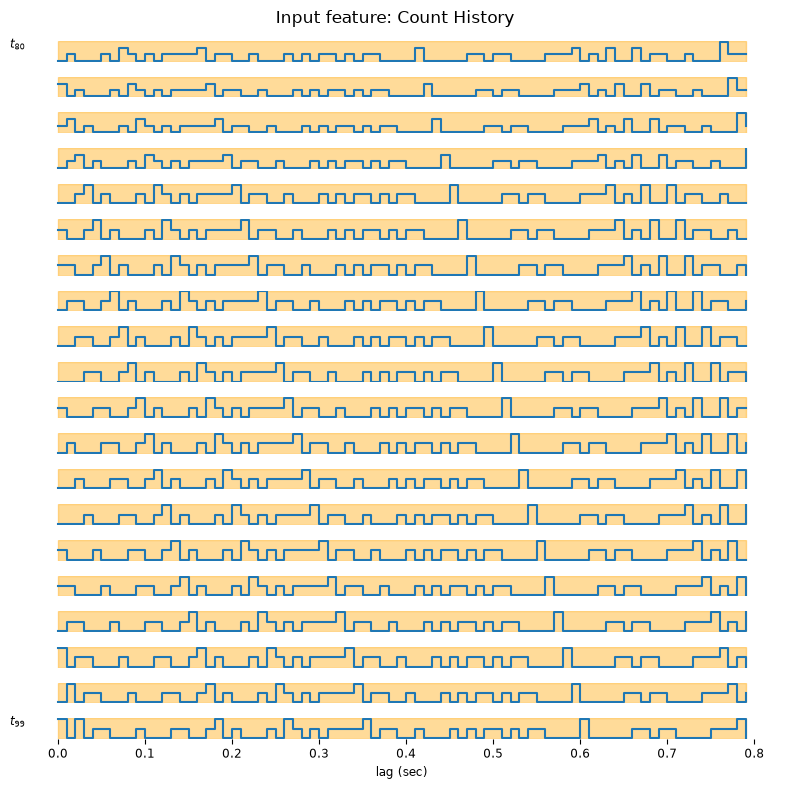

In [34]:
suptitle = "Input feature: Count History"
neuron_id = 0
fig = workshop_utils.plot_features(input_feature, count.rate, suptitle)

In [35]:
fig.savefig("../../_static/_check_figs/02-02.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-02.png)
:::
</div>


<div class="render-all">

The time axis runs backward because convolution reverses it — this is equivalent, and we can interpret each weight as the influence of a spike at that lag on the future firing rate. With 10 ms bins and a 0.8 s window the feature has 80 dimensions. We will learn these 80 weights by maximum likelihood.

</div>


#### Fitting a single neuron model

<div class="render-all">

When working with real data it is good practice to train on one portion and evaluate on another — a process known as cross-validation. The optimal strategy depends on data structure (continuous time series vs. independent trials). Here we use a simple first-half/second-half split, which is reasonable provided the firing statistics are stationary across the recording.

</div>

In [36]:
# construct the train and test epochs
duration = input_feature.time_support.tot_length("s")
start = input_feature.time_support["start"]
end = input_feature.time_support["end"]

# define the interval sets
first_half = nap.IntervalSet(start, start + duration / 2)
second_half = nap.IntervalSet(start + duration / 2, end)

<div class="render-all">

**Question: Can you fit the glm to the first half of the recording and visualize the maximum likelihood weights?**

The model used should be a `nmo.glm.GLM` with the solver `LBFGS`.

</div>

<div class="render-user">
```{code-cell} ipython3
# define the GLM object
model = nmo.glm.GLM() # Parameter is the solver name
# Fit over the training epochs
model.fit(
    input_feature.restrict(), # Parameter is the feature matrix restricted to the first half
    neuron_count.restrict() # Parameter is the binned spike count time series restricted to the first half
)
```
</div>

In [37]:
# define the GLM object
model = nmo.glm.GLM(solver_name="LBFGS")

# Fit over the training epochs
model.fit(
    input_feature.restrict(first_half),
    neuron_count.restrict(first_half)
)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f038c4b09a0>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](80,)",Array([ 6.171...dtype=float64)
dof_resid_,"ArrayImpl[float64](1,)","Array([8999.], dtype=float64)"
intercept_,"ArrayImpl[float64](1,)",Array([-2.785...dtype=float64)


<div class="render-all">

Each weight represents the influence of a spike at time lag $i$ on the log-rate at time $t$. Let's plot the learned filter.

</div>

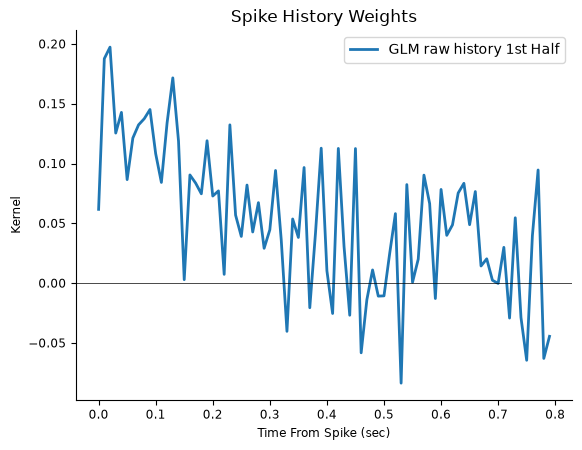

In [38]:
fig = plt.figure()
plt.title("Spike History Weights")
plt.plot(np.arange(window_size) / count.rate, np.squeeze(model.coef_), lw=2, label="GLM raw history 1st Half")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time From Spike (sec)")
plt.ylabel("Kernel")
plt.legend()

In [39]:
fig.savefig("../../_static/_check_figs/02-03.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-03.png)
:::
</div>

<div class="render-all">

The filter looks like a decaying exponential buried in noise, suggesting it can be described with far fewer degrees of freedom than 80 raw weights. If the noise reflects over-fitting, the weights should differ substantially between the two halves of the data.

</div>


<div class="render-all">

**Question: Can you fit a new model on the second half of the data and call it `model_second_half`?**

</div>

<div class="render-user">
```{code-cell} ipython3
# fit on the other half of the data
model_second_half =  # Parameter is the solver name
model_second_half.fit(
    , # Parameter is the feature matrix restricted to the second half
     # Parameter is the binned spike count time series restricted to the second half
)
```
</div>

In [40]:
# fit on the other half of the data

model_second_half = nmo.glm.GLM(solver_name="LBFGS")
model_second_half.fit(
    input_feature.restrict(second_half),
    neuron_count.restrict(second_half)
)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f038c4b09a0>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](80,)",Array([ 0.089...dtype=float64)
dof_resid_,"ArrayImpl[float64](1,)","Array([8919.], dtype=float64)"
intercept_,"ArrayImpl[float64](1,)",Array([-3.259...dtype=float64)


<div class="render-all">

Let's plot the weights learned on the second half of the data and compare them to those learned on the first half.

</div>

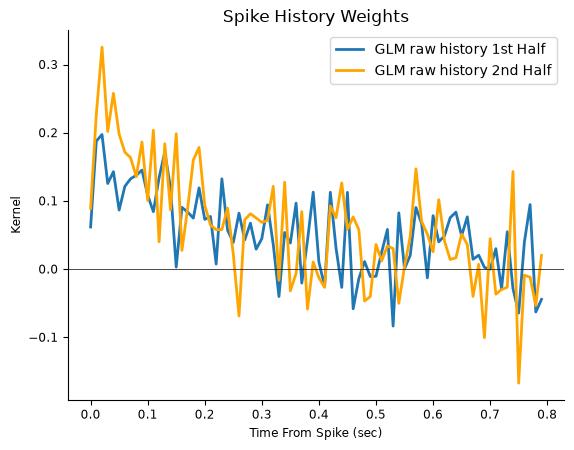

In [41]:
fig = plt.figure()
plt.title("Spike History Weights")
plt.plot(np.arange(window_size) / count.rate, np.squeeze(model.coef_),
         label="GLM raw history 1st Half", lw=2)
plt.plot(np.arange(window_size) / count.rate,  np.squeeze(model_second_half.coef_),
         color="orange", label="GLM raw history 2nd Half", lw=2)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time From Spike (sec)")
plt.ylabel("Kernel")
plt.legend()

In [42]:
fig.savefig("../../_static/_check_figs/02-04.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-04.png)
:::
</div>

<div class="render-all">

The high-frequency fluctuations are inconsistent between the two fits, confirming they reflect noise rather than signal — a hallmark of over-fitting. The underlying decaying trend is consistent, but masked by noise. At 1 ms resolution this would be far worse: 800 coefficients instead of 80. We need a way to reduce dimensionality while preserving the smooth structure of the filter.

</div>

#### Reducing feature dimensionality

<div class="render-all">
NeMoS' `basis` module lets us reparametrize the filter in terms of a small set of smooth basis functions, greatly reducing dimensionality. For spike-history inputs the standard choice is the raised cosine log-stretched basis ([Pillow et al., 2005](https://www.jneurosci.org/content/25/47/11003)), shown below.

</div>

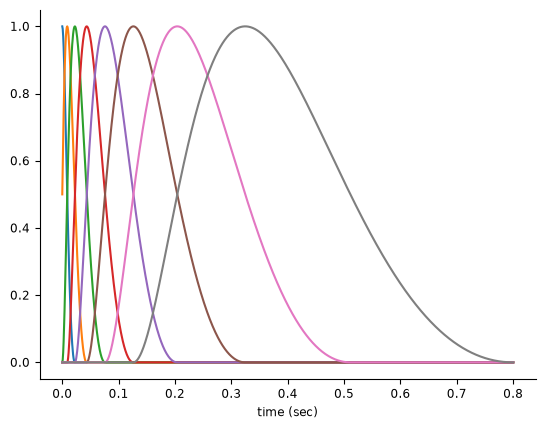

In [43]:
fig = doc_plots.plot_basis()

In [44]:
fig.savefig("../../_static/_check_figs/02-05.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-05.png)
:::
</div>

:::{note}

Choosing the right basis is an important modelling decision. NeMoS provides several options. The raised cosine log-stretched basis is a well-established choice for spike history; the log-stretch gives finer resolution at short lags where neural effects are strongest.
:::

<div class="render-all">

We initialize `RaisedCosineLogConv` by specifying the number of basis functions and the convolution window size. More basis functions give finer temporal resolution at the cost of additional parameters to estimate.

**Question: Can you define the basis `RaisedCosineLogConv`and name it `basis`?**

Basis parameters:
- 8 basis functions.
- Window size of 0.8sec.

</div>


<div class="render-user">
```{code-cell} ipython3
# a basis object can be instantiated in "conv" mode for convolving the input.
basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs=, # Number of basis functions
    window_size= # Window size in bins
)
```
</div>

In [45]:
# a basis object can be instantiated in "conv" mode for convolving  the input.
basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs=8, window_size=window_size
)

<div class="render-all">

The raw history predictor had 80 values per time point — an order of magnitude more than the 8 basis coefficients we use instead. Beyond the memory and speed gain, the compression directly reduces over-fitting by constraining the filter to a smooth subspace. At 1 ms resolution the saving would be two orders of magnitude.

To apply the basis, call `compute_features` — this convolves the counts with the basis kernels without materializing the large raw-history matrix.

**Question: Can you:**
- Convolve the counts with the basis functions. (Call the output `conv_spk`)
- Print the shape of `conv_spk` and compare it to `input_feature`.

</div>

<div class="render-user">
```{code-cell} ipython3
# equivalent to
# `nmo.convolve.create_convolutional_predictor(basis_kernels, neuron_count)`
conv_spk = basis.compute_features() # Parameter is the binned spike count time series
print(f"Raw count history as feature: {input_feature.shape}")
print(f"Compressed count history as feature: {conv_spk.shape}")
```
</div>

In [46]:
# equivalent to
# `nmo.convolve.create_convolutional_predictor(basis_kernels, neuron_count)`
conv_spk = basis.compute_features(neuron_count)

print(f"Raw count history as feature: {input_feature.shape}")
print(f"Compressed count history as feature: {conv_spk.shape}")

Raw count history as feature: (18000, 80)
Compressed count history as feature: (18000, 8)


<div class="render-all">

Let's visualize the convolved features over two short windows — one with a single spike and one with multiple spikes — to see how the basis captures the history.

</div>

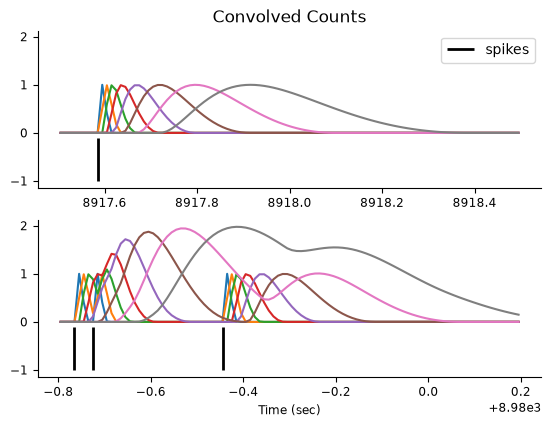

In [47]:
# Visualize the convolution results
epoch_one_spk = nap.IntervalSet(8917.5, 8918.5)
epoch_multi_spk = nap.IntervalSet(8979.2, 8980.2)

fig = doc_plots.plot_convolved_counts(neuron_count, conv_spk, epoch_one_spk, epoch_multi_spk)

In [48]:
fig.savefig("../../_static/_check_figs/02-06.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-06.png)
:::
</div>

#### Fit a GLM with basis features with reduced dimensionality

<div class="render-all">

Now that we have our "compressed" history feature matrix, we can fit the parameters for a new GLM model using these features.

**Question: Can you fit the model using the compressed features? Call it `model_basis`.**

</div>

<div class="render-user">
```{code-cell} ipython3
# use restrict on interval set training
model_basis = nmo.glm.GLM() # Parameter is the solver name
model_basis.fit(
    , # Parameter is the convolved feature matrix restricted to the first half
     # Parameter is the binned spike count time series restricted to the first half
)
```
</div>

In [49]:
# use restrict on interval set training
model_basis = nmo.glm.GLM(solver_name="LBFGS")
model_basis.fit(conv_spk.restrict(first_half), neuron_count.restrict(first_half))

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f038c4b09a0>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](8,)",Array([-0.025...dtype=float64)
dof_resid_,"ArrayImpl[float64](1,)","Array([8999.], dtype=float64)"
intercept_,"ArrayImpl[float64](1,)",Array([-2.756...dtype=float64)


<div class="render-all">

(head-direction-basis-full)=

The model learned 8 coefficients — one per basis function. To recover the full history filter in the original time domain we project them back through the basis kernels.

</div>

In [50]:
print(model_basis.coef_)

[-0.02592858  0.16032946  0.07191899  0.07063986  0.03755858  0.10458721
 -0.01092549  0.05780688]


<div class="render-all">

We reconstruct the history filter by multiplying the basis kernels (from `evaluate_on_grid`) by the learned coefficients using `np.matmul`.

</div>

In [51]:
# get the basis function kernels
_, basis_kernels = basis.evaluate_on_grid(window_size)

# multiply with the weights
self_connection = np.matmul(basis_kernels, model_basis.coef_)

print(self_connection.shape)

(80,)


<div class="render-all">

To check whether the basis model is more stable than the raw-history model, we refit on the second half and compare the two filter estimates.

</div>

In [52]:
# fit on the other half of the data
model_basis_second_half = nmo.glm.GLM(solver_name="LBFGS").fit(
    conv_spk.restrict(second_half), neuron_count.restrict(second_half)
)
self_connection_second_half = np.matmul(basis_kernels, model_basis_second_half.coef_)

<div class="render-all">

Let's plot the weights learned on the second half of the data and compare them to those learned on the first half.

</div>

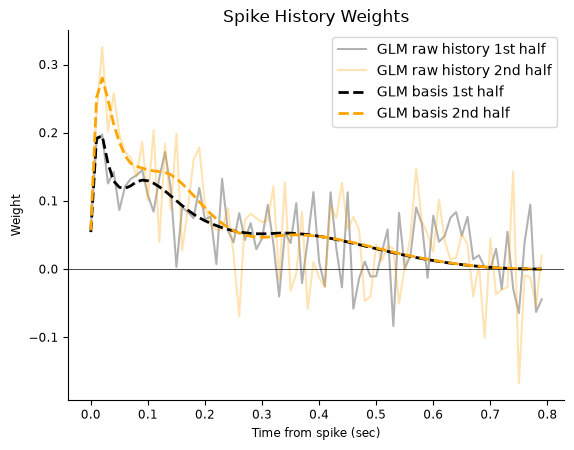

In [53]:
time = np.arange(window_size) / count.rate
fig = plt.figure()
plt.title("Spike History Weights")
plt.plot(time, np.squeeze(model.coef_), "k", alpha=0.3, label="GLM raw history 1st half")
plt.plot(time, np.squeeze(model_second_half.coef_), alpha=0.3, color="orange", label="GLM raw history 2nd half")
plt.plot(time, self_connection, "--k", lw=2, label="GLM basis 1st half")
plt.plot(time, self_connection_second_half, color="orange", lw=2, ls="--", label="GLM basis 2nd half")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time from spike (sec)")
plt.ylabel("Weight")
plt.legend()

In [54]:
fig.savefig("../../_static/_check_figs/02-07.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-07.png)
:::
</div>

<div class="render-all">

**Question:** Can you predict the firing rate from both `model` (raw history) and `model_basis` (basis)? Call the outputs `rate_history` and `rate_basis`, converting from spikes/bin to spikes/s.

</div>

<div class="render-user">
```{code-cell} ipython3
rate_basis = model_basis.predict() # Parameter is the convolved feature matrix
rate_history = model.predict() # Parameter is the original feature
# convert the rate from spike/bin to spike/sec by multiplying with neuron_count.rate
rate_basis = rate_basis * conv_spk.rate
rate_history = rate_history * conv_spk.rate
```
</div>

In [55]:
rate_basis = model_basis.predict(conv_spk) * conv_spk.rate
rate_history = model.predict(input_feature) * conv_spk.rate

<div class="render-all">

Let's compare predicted and smoothed observed rates over a short test window.

</div>

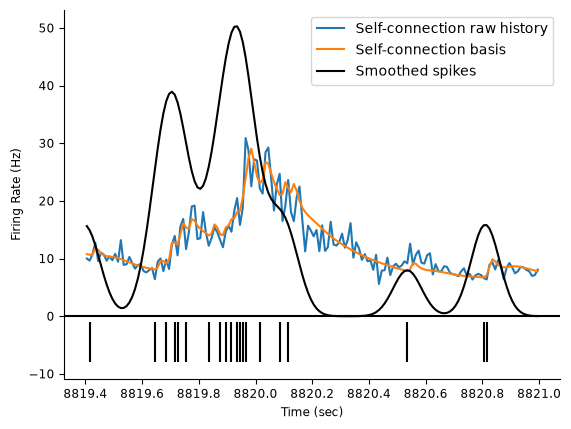

In [56]:
# plot the rates
fig = doc_plots.plot_rates_and_smoothed_counts(
    neuron_count,
    {"Self-connection raw history":rate_history, "Self-connection basis": rate_basis}
);

In [57]:
fig.savefig("../../_static/_check_figs/02-08.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-08.png)
:::
</div>

#### All-to-all Connectivity

<div class="render-all">

We now extend the model to the full population: each neuron's firing rate is predicted from the recent spike history of all simultaneously recorded neurons. Convolving the basis with each neuron's counts gives a predictor array of shape `(num_time_points, num_neurons * num_basis_funcs)`.

</div>

#### Preparing the features

<div class="render-all">

**Question:** Can you convolve all neurons and store the result in `convolved_count`?

Because we are now passing a multi-neuron array, call `basis.set_input_shape(count)` first so the basis knows the expected input dimensionality.

</div>

<div class="render-user">
```{code-cell} ipython3
# reset the input shape by passing the pop. count
print(count.shape)
print(152/8)
basis.set_input_shape(count)
# convolve all the neurons
convolved_count = basis.compute_features() # Parameter is the binned spike count time series
```
</div>

In [58]:
# reset the input shape by passing the pop. count
print(count.shape)
print(152/8)

basis.set_input_shape(count)

# convolve all the neurons
convolved_count = basis.compute_features(count)

(18000, 18)
19.0


<div class="render-all">

Verify that the output shape is `(n_samples, n_basis_funcs × n_neurons)`.

</div>

In [59]:
print(f"Convolved count shape: {convolved_count.shape}")

Convolved count shape: (18000, 144)


(head-direction-fit-full)=
#### Fitting the Model

<div class="render-all">

We use [`PopulationGLM`](https://nemos.readthedocs.io/en/latest/generated/glm/nemos.glm.PopulationGLM.html) to fit all neurons at once. Conditioned on past activity, the population log-likelihood is the sum of individual neuron log-likelihoods, so joint fitting is equivalent to fitting each neuron independently — but more convenient.

**Question: Can you:**
- Fit a `PopulationGLM`? Call the object `model`. Solver should be `LBFGS`.
- Use Ridge regularization with a `regularizer_strength=0.1`?
- Print the shape of the estimated coefficients.

</div>

<div class="render-user">
```{code-cell} ipython3
model = nmo.glm.PopulationGLM(
    regularizer=, # Regularizer type
    solver_name=, # Solver name
    regularizer_strength= # Regularization strength
    ).fit( , ) # Parameters are the convolved feature matrix and the binned spike count time series
print(f"Model coefficients shape: {model.coef_.shape}")
```
</div>

In [60]:
model = nmo.glm.PopulationGLM(
    regularizer="Ridge",
    solver_name="LBFGS",
    regularizer_strength=0.1
    ).fit(convolved_count, count)

print(f"Model coefficients shape: {model.coef_.shape}")

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/.venv/lib/python3.12/site-packages/nemos/glm/glm.py:841: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


Model coefficients shape: (144, 18)


#### Comparing model predictions.

<div class="render-all">

The neuron columns are sorted by preferred direction.

**Question:** Can you predict the firing rate of each neuron from `convolved_count` (call it `predicted_firing_rate`) and convert from spikes/bin to spikes/s?

</div>

<div class="render-user">
```{code-cell} ipython3
predicted_firing_rate = model.predict() # Parameter is the convolved feature matrix
# convert the rate from spike/bin to spike/sec by multiplying with conv_spk.rate
predicted_firing_rate = predicted_firing_rate * conv_spk.rate
```
</div>

In [61]:
predicted_firing_rate = model.predict(convolved_count) * conv_spk.rate

<div class="render-all">

Let's compare the model-predicted tuning curves against the empirical ones and inspect the predicted firing rate over time.

</div>

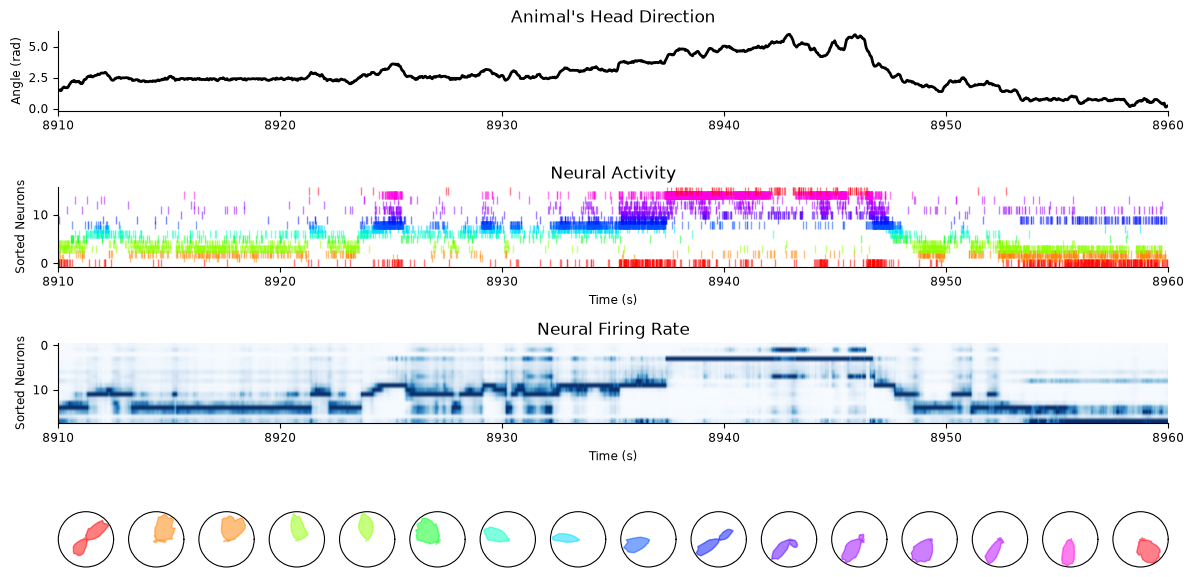

In [62]:
# use pynapple for time axis for all variables plotted for tick labels in imshow
fig = workshop_utils.plot_head_direction_tuning_model(tuning_curves, spikes, angle, 
                                                predicted_firing_rate, threshold_hz=1,
                                                start=8910, end=8960, cmap_label="hsv");

In [63]:
fig.savefig("../../_static/_check_figs/02-09.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-09.png)
:::
</div>

<div class="render-all">

Let's overlay all three model predictions — raw history, single-neuron basis, and all-to-all basis — on the same neuron to assess the improvement.

</div>

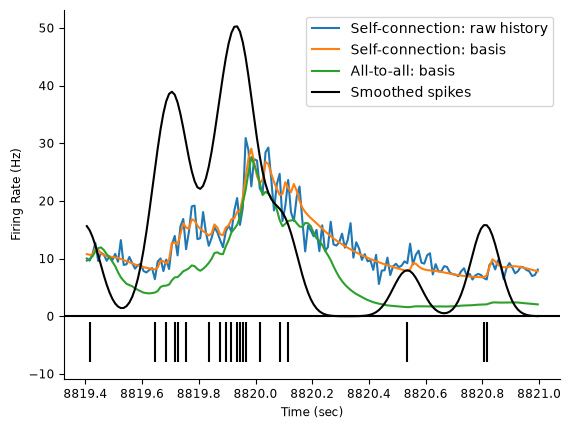

In [64]:
fig = doc_plots.plot_rates_and_smoothed_counts(
    neuron_count,
    {"Self-connection: raw history": rate_history,
     "Self-connection: basis": rate_basis,
     "All-to-all: basis": predicted_firing_rate[:, 0]}
)

In [65]:
fig.savefig("../../_static/_check_figs/02-10.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-10.png)
:::
</div>

#### Visualizing the connectivity

<div class="render-all">

Finally, we can extract and visualize the pairwise coupling filters.

**Question:** Can you reshape the coefficient matrix into a `(n_neurons, n_neurons, n_basis_funcs)` array using `basis.split_by_feature`?

</div>

In [66]:
# original shape of the weights
print(f"GLM coeff: {model.coef_.shape}")

GLM coeff: (144, 18)


<div class="render-all">

You can use the `split_by_feature` method of `basis` for this. It will reshape the coefficient vector into a 3D array.

![Reshape coefficients](../../_static/coeff_reshape.png)

</div>

<div class="render-user">
```{code-cell} ipython3
# split the coefficient vector along the feature axis (axis=0)
weights_dict = basis.split_by_feature() # Parameter is the model coefficients. Axis is 0
# The output is a dict with key the basis label, 
# and value the reshaped coefficients
weights = weights_dict["RaisedCosineLogConv"]
print(f"Re-shaped coefficients: {weights.shape}")
```
</div>

In [67]:
# split the coefficient vector along the feature axis (axis=0)
weights_dict = basis.split_by_feature(model.coef_, axis=0)

# the output is a dict with key the basis label, 
# and value the reshaped coefficients
weights = weights_dict["RaisedCosineLogConv"]
print(f"Re-shaped coeff: {weights.shape}")

Re-shaped coeff: (18, 8, 18)


<div class="render-all">

The shape is `(sender_neuron, num_basis, receiver_neuron)`. We project back through the basis kernels with `np.einsum` to get the full coupling filters:

`(sender, num_basis, receiver) × (time_lag, num_basis) → (sender, receiver, time_lag)`

</div>

In [68]:
responses = np.einsum("jki,tk->ijt", weights, basis_kernels)

print(responses.shape)

(18, 18, 80)


<div class="render-all">

Each entry in the grid shows how strongly neuron *j*'s past activity drives neuron *i*'s firing rate, with both axes sorted by preferred direction.

</div>

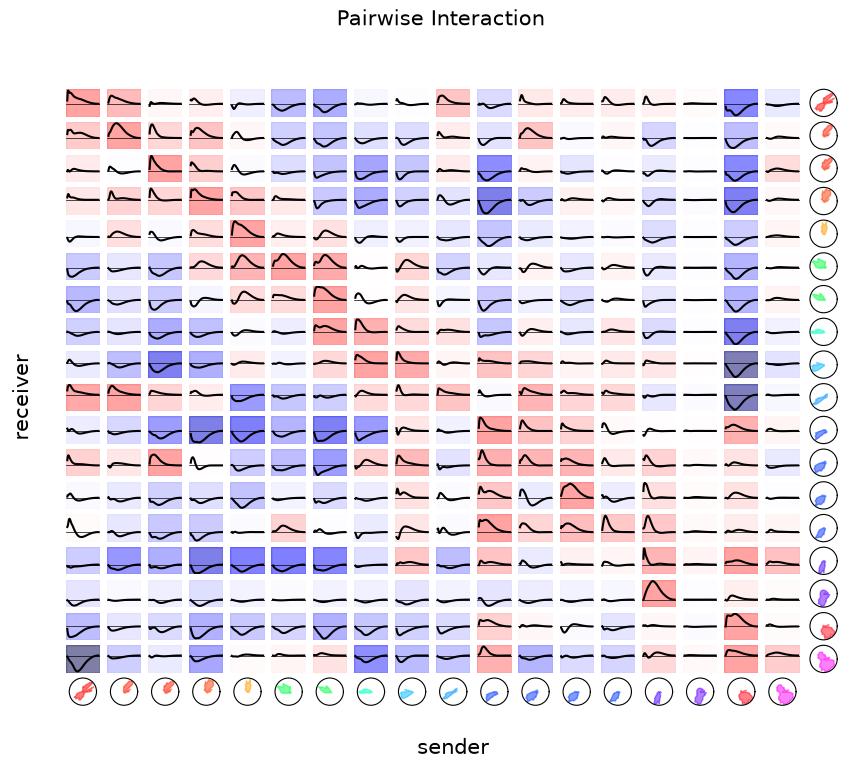

In [69]:
predicted_tuning_curves = nap.compute_tuning_curves(
    data=predicted_firing_rate,
    features=angle, 
    bins=61, 
    epochs = angle.time_support,
    range=(0, 2 * np.pi),
    feature_names = ["angle"]
    )

                                                 
fig = workshop_utils.plot_coupling_filters(responses, predicted_tuning_curves)

In [70]:
fig.savefig("../../_static/_check_figs/02-11.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-11.png)
:::
</div>

<div class="render-all">

These coupling filters capture the functional influence of each neuron on every other, sorted by preferred direction. Neurons with similar preferences show positive coupling; those with opposing preferences show negative coupling. These are functional connections inferred from shared tuning, not direct synaptic contacts.
</div>

## Part 2: Calcium imaging

### Analyzing calcium imaging with Pynapple

<div class="render-all">

We will now analyze calcium imaging data of head-direction cells recorded in the postsubiculum of the mouse.
We will use a NWB file containing deconvolved calcium events of neurons and the head-direction of the animal over time.
We will study the tuning properties of neurons with tuning curves, decode the head-direction from neural activity,
and fit a GLM with a Gaussian observation model suited to continuous fluorescence data.

</div>

#### Load data

<div class="render-all">

Similar to the previous section, we will start by loading a NWB file with `nap.load_file`.
Let's fetch the data first.

</div>

In [71]:
path = workshop_utils.fetch_data("A0670-221213.nwb")
print(path)

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/data/A0670-221213.nwb


<div class="render-user">
```{code-cell} ipython3
data =  # Load NWB file
print(data)
```
</div>

In [72]:
data = nap.load_file(path)

print(data)

A0670-221213
┍━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                  │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ position_time_support │ IntervalSet │
│ RoiResponseSeries     │ TsdFrame    │
│ z                     │ Tsd         │
│ y                     │ Tsd         │
│ x                     │ Tsd         │
│ rz                    │ Tsd         │
│ ry                    │ Tsd         │
│ rx                    │ Tsd         │
┕━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


<div class="render-all">

There are multiple entries in the NWB file. The calcium transients are stored in the `RoiResponseSeries` entry.
The head-direction of the animal is stored in the `ry` entry. Let's extract them.

</div>

In [73]:
transients = data["RoiResponseSeries"]
angle = data["ry"]
print(transients)

Time (s)          0        1         2         3         4  ...
----------  -------  -------  --------  --------  --------  -----
3.1187      0.27546  0.79973  0.16383   0.20118   0.029255  ...
3.15225     0.26665  0.86751  0.15879   0.23682   0.027189  ...
3.18585     0.25796  0.89419  0.15352   0.25074   0.036514  ...
3.2194      0.24943  0.89513  0.14812   0.25215   0.056273  ...
3.253       0.24111  0.88023  0.14898   0.24651   0.070954  ...
3.28655     0.233    0.85584  0.14858   0.23706   0.081469  ...
3.32015     0.22513  1.0996   0.14715   0.22572   0.088588  ...
...                                                         ...
1203.38945  0.20815  0.17535  0.12126   0.094461  0.87427   ...
1203.42305  0.20247  0.17243  0.11807   0.089918  1.2578    ...
1203.4566   0.19654  0.17056  0.11461   0.085079  1.62      ...
1203.4902   0.19052  0.16645  0.11096   0.080197  1.8811    ...
1203.52375  0.18449  0.16105  0.10717   0.075416  2.0599    ...
1203.55735  0.17851  0.15494  0.10331 

<div class="render-all">

To get an idea of the data, let's visualize the calcium transients of the first two neurons for the first 100 seconds of the recording.
Instead of creating a new `IntervalSet` object, we can use the method `transients.get(0, 100)` to get a restricted version of the `Tsd` object.
Contrary to `restrict`, which takes an `IntervalSet` object as input, `get` can take start and end times directly as input and does not 
update the time support of the output `Tsd` object.

</div>

Text(0, 0.5, 'Fluorescence (a.u.)')

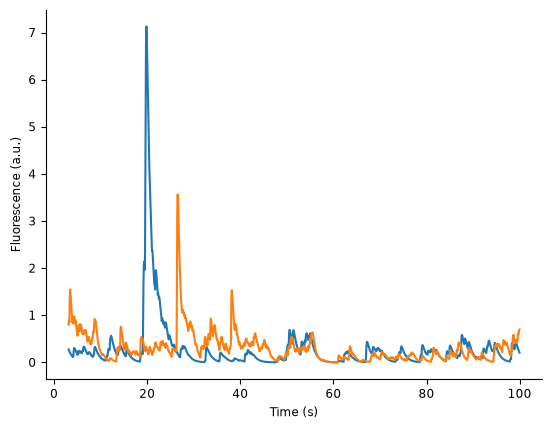

In [74]:
fig = plt.figure()
plt.plot(transients[:,0:2].get(0, 100))
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence (a.u.)")

In [75]:
fig.savefig("../../_static/_check_figs/01-04.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-04.png)
:::
</div>

#### Compute tuning curves

<div class="render-all">

We now have calcium transients and a behavioral feature (head-direction). We can compute **tuning curves** — the mean fluorescence of each neuron as a function of head-direction — using the same `nap.compute_tuning_curves` call as in Part 1. Remember to pass `feature_names = ["angle"]` so the output dimension is labelled.

</div>

<div class="render-user">
```{code-cell} ipython3
tuning_curves = nap.compute_tuning_curves(
    data=, # The neural activity as a TsdFrame
    features=, # Which feature? Here the head-direction of the animal
    bins=, # How many bins of feature space? Here 61 angular bins is a good number
    range=, # The min and max of the bin array
    feature_names= # Let's give a name to our feature for better labelling of the output.
    )
tuning_curves
```
</div>

In [76]:
tuning_curves = nap.compute_tuning_curves(
    data=transients,
    features=angle,
    bins=61,
    epochs=angle.time_support,
    range=(0, 2 * np.pi),
    feature_names=["angle"]
    )

tuning_curves

<xarray.DataArray (unit: 65, angle: 61)> Size: 32kB
array([[0.336294  , 0.39249376, 0.28825878, ..., 0.36234269, 0.2708909 ,
        0.28310301],
       [0.05395929, 0.04359246, 0.04214995, ..., 0.07306646, 0.06231189,
        0.05681652],
       [0.15342062, 0.17939499, 0.15450186, ..., 0.1853742 , 0.11779423,
        0.12548764],
       ...,
       [0.09231561, 0.09080612, 0.06466286, ..., 0.13556026, 0.1133827 ,
        0.09577019],
       [0.10206325, 0.08374734, 0.07383455, ..., 0.11335814, 0.10032206,
        0.09266054],
       [0.09586888, 0.13690644, 0.16440948, ..., 0.0797701 , 0.08365685,
        0.0929572 ]], shape=(65, 61))
Coordinates:
  * unit     (unit) int64 520B 0 1 2 3 4 5 6 7 8 ... 56 57 58 59 60 61 62 63 64
  * angle    (angle) float64 488B 0.0515 0.1545 0.2575 ... 6.026 6.129 6.232
Attributes:
    occupancy:  [1898. 2249. 2064. 1962. 2081. 2249. 2544. 2511. 2045. 2498. ...
    bin_edges:  [array([0.        , 0.10300304, 0.20600608, 0.30900911, 0.412...
    fs:         120.00514660424693

#### Visualize tuning curves

<div class="render-all">

Let's visualize the tuning curves of the first two neurons.

</div>

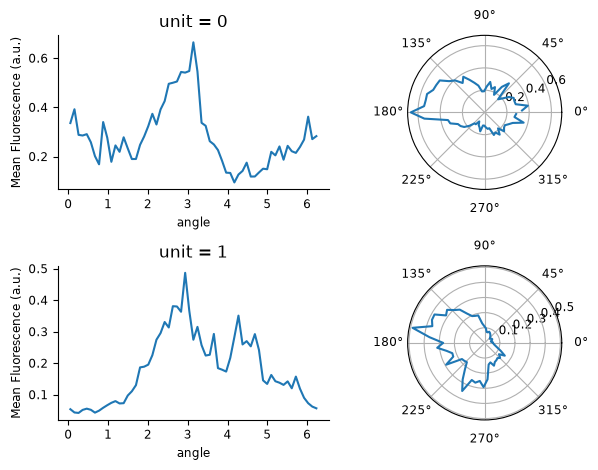

In [77]:
fig = plt.figure()
plt.subplot(221)
tuning_curves[0].plot()
plt.ylabel("Mean Fluorescence (a.u.)")
plt.subplot(222, projection='polar')
plt.plot(tuning_curves.angle, tuning_curves[0].values)
plt.subplot(223)
tuning_curves[1].plot()
plt.ylabel("Mean Fluorescence (a.u.)")
plt.subplot(224, projection='polar')
plt.plot(tuning_curves.angle, tuning_curves[1].values)
plt.tight_layout()

In [78]:
fig.savefig("../../_static/_check_figs/01-05.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-05.png)
:::
</div>

#### Decode head-direction from neural activity

<div class="render-all">

Now that we have the tuning curves, we can use them to decode the head-direction of the animal from the neural activity.
Pynapple provides two functions to do this: `nap.decode_bayes` for spike counts and `nap.decode_template` for event rates or continuous data.
Since the data are calcium transients and not spike counts, we will use the template matching method.

**Question:** Can you decode the head-direction of the animal using the function `nap.decode_template` and call the variable `decoded_angle`?

We will use the epoch `epochs = nap.IntervalSet(start=50, end=150)` to restrict the decoding to 100 seconds of the recording.

</div>

<div class="render-user">
```{code-cell} ipython3
epochs = nap.IntervalSet(start=50, end=150)
decoded_angle, dist = nap.decode_template(
    tuning_curves= , # The tuning curves as an xarray object
    data= , # The neural activity as a TsdFrame
    bin_size= , # The bin size for decoding. Here I suggest 0.1 second
    metric= , # The metric to compare neural activity to tuning curves. Here I suggest "correlation"
    epochs=epochs
    )
```
</div>

In [79]:
epochs = nap.IntervalSet(start=50, end=150)
decoded_angle, dist = nap.decode_template(
    tuning_curves=tuning_curves,
    data=transients,
    bin_size=0.1,
    metric="correlation",
    epochs=epochs
    )

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/.venv/lib/python3.12/site-packages/pynapple/process/decoding.py:48: UserWarning: passed bin_size is different from actual data bin size.
  warnings.warn("passed bin_size is different from actual data bin size.")


<div class="render-all">

Let's compare the decoded angle against the true head-direction and inspect the decoder's confidence across angles over time.

</div>

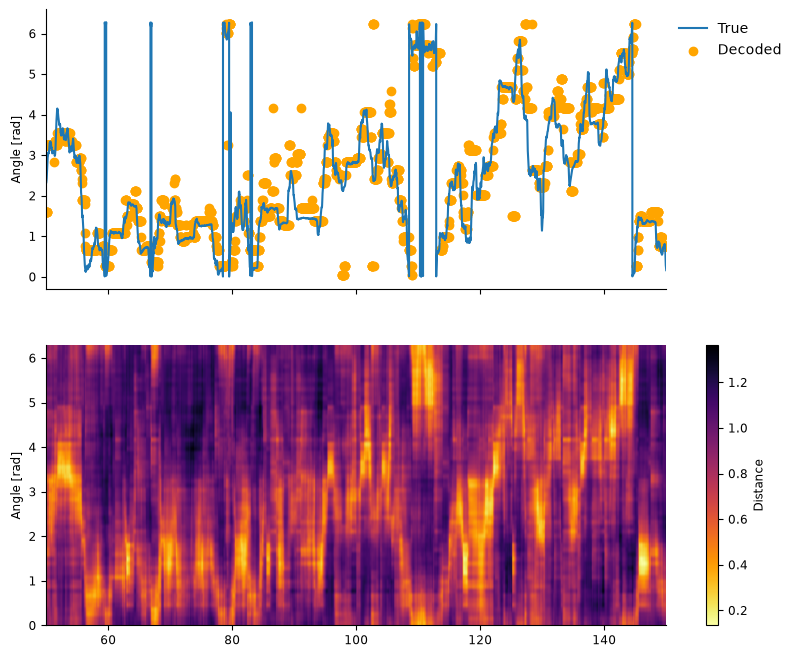

In [80]:
fig, (ax1, ax2) = plt.subplots(figsize=(8, 8), nrows=2, ncols=1, sharex=True)
ax1.plot(angle.restrict(epochs), label="True")
ax1.scatter(decoded_angle.times(), decoded_angle.values, label="Decoded", c="orange")
ax1.legend(frameon=False, bbox_to_anchor=(1.0, 1.0))
ax1.set_ylabel("Angle [rad]")

im = ax2.imshow(
    dist.values.T,
    aspect="auto",
    origin="lower",
    cmap="inferno_r",
    extent=(epochs.start[0], epochs.end[0], 0.0, 2*np.pi)
)
ax2.set_ylabel("Angle [rad]")
cbar_ax2 = fig.add_axes([0.95, ax2.get_position().y0, 0.015, ax2.get_position().height])
fig.colorbar(im, cax=cbar_ax2, label="Distance")

In [81]:
fig.savefig("../../_static/_check_figs/01-06.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/01-06.png)
:::
</div>

<div class="render-all">

The top panel overlays the decoded angle on the true head-direction. The bottom panel shows the template-matching distance at each candidate angle over time — the trough tracks the decoded position. Try different `metric` values (`"euclidean"`, `"manhattan"`, `"correlation"`, `"jensenshannon"`, `"cosine"`) to see how the choice affects decoding accuracy.

</div>

### Modelling calcium imaging data with GLM

<div class="render-all">

Calcium imaging data differs from spike data in two key ways: the signal is continuous-valued (fluorescence rather than counts), and its dynamics are slower due to calcium indicator kinetics. These differences call for two model changes: a Gaussian observation model instead of Poisson, and a basis window tuned to the slower temporal structure.

</div>

#### Preprocessing the data

<div class="render-all">

Before fitting the GLM we keep only neurons significantly tuned to head-direction (Rayleigh test, p < 0.01). This reduces dimensionality and speeds up fitting.

</div>

In [82]:
C = np.sum(tuning_curves.values * np.cos(tuning_curves.angle.values), axis=1) / np.sum(tuning_curves.values, axis=1)
S = np.sum(tuning_curves.values * np.sin(tuning_curves.angle.values), axis=1) / np.sum(tuning_curves.values, axis=1)
R = np.sqrt(C**2 + S**2)
Z = tuning_curves.shape[1] * R**2
p_value = np.exp(-Z)

tokeep_neurons = np.where(p_value < 0.01)[0]
transients = transients[:, tokeep_neurons]
tuning_curves = tuning_curves[tokeep_neurons]
print(f"Number of neurons after tuning selection: {transients.shape[1]}")

Number of neurons after tuning selection: 16


<div class="render-all">

Finally, we sort the neurons based on their preferred head-direction.

</div>

In [83]:
pref_ang = tuning_curves.idxmax(dim="angle")
sort_idx = np.argsort(pref_ang.values)
transients = transients[:, sort_idx]
tuning_curves = tuning_curves[sort_idx]
pref_ang = pref_ang[sort_idx]
transients.set_info(pref_ang=pref_ang)
print(transients)

Time (s)    64         6           17       49        1        ...
----------  ---------  ----------  -------  --------  -------  -----
3.1187      0.1564     8.0399e-11  0.11318  0.17587   0.79973  ...
3.15225     0.15096    7.5078e-11  0.10589  0.16596   0.86751  ...
3.18585     0.14533    7.0109e-11  0.10145  0.1566    0.89419  ...
3.2194      0.13983    6.5469e-11  0.14243  0.15677   0.89513  ...
3.253       0.13452    6.1136e-11  0.16411  0.15343   0.88023  ...
3.28655     0.12941    5.709e-11   0.17343  0.24614   0.85584  ...
3.32015     0.12449    5.3312e-11  0.17497  0.25991   1.0996   ...
...                                                            ...
1203.38945  0.0053469  0.069231    0.15937  0.090531  0.17535  ...
1203.42305  0.0051438  0.064979    0.15854  0.085426  0.17243  ...
1203.4566   0.0049484  0.060901    0.15421  0.080609  0.17056  ...
1203.4902   0.0047604  0.057022    0.14785  0.076063  0.16645  ...
1203.52375  0.0045795  0.053351    0.1404   0.071773  0.1610

#### Basis functions for calcium data

<div class="render-all">

We use the same `RaisedCosineLogConv` basis but with fewer, broader basis functions over a 0.5 s window — appropriate for the slower dynamics of calcium signals compared to spikes.

**Question: Can you define a `RaisedCosineLogConv` basis and name it `calcium_basis`?**

Basis parameters:
- 4 basis functions.
- Window size of 0.5 sec.

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_window_size_sec = 0.5
calcium_window_size = int(calcium_window_size_sec * transients.rate)
calcium_basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs= , # Number of basis functions
    window_size=calcium_window_size
)
calcium_basis
```
</div>

In [84]:
calcium_window_size_sec = 0.5
calcium_window_size = int(calcium_window_size_sec * transients.rate)
calcium_basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs=4, window_size=calcium_window_size
)
print(calcium_window_size)
calcium_basis

14


,n_basis_funcs,4
,window_size,14
,time_scaling,50.0
,conv_kwargs,{}
,width,2.0
,enforce_decay_to_zero,True
,label,'RaisedCosineLogConv'


#### Preparing the features

<div class="render-all">

We can convolve the calcium transients with the basis functions to get the feature matrix.

**Question: Can you convolve all neurons and call the output `calcium_convolved`?**

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_convolved = calcium_basis.compute_features( ) # Parameter is the calcium transients
print(f"Convolved calcium shape: {calcium_convolved.shape}")
```
</div>

In [85]:
calcium_convolved = calcium_basis.compute_features(transients)
print(f"Convolved calcium shape: {calcium_convolved.shape}")

Convolved calcium shape: (35757, 64)


#### Fitting a Gaussian Population GLM

<div class="render-all">

We fit a `PopulationGLM` with a Gaussian observation model, which is appropriate for continuous-valued fluorescence data. As before, we split the recording into a training first-half and a testing second-half.

</div>

In [86]:
duration = calcium_convolved.time_support.tot_length("s")
start = calcium_convolved.time_support["start"]
end = calcium_convolved.time_support["end"]
training_ep = nap.IntervalSet(start, start + duration / 2)
testing_ep = nap.IntervalSet(start + duration / 2, end)

<div class="render-all">

**Question: Can you fit a `PopulationGLM` with a Gaussian observation model, Ridge regularization, strength 0.001, and LBFGS solver? Call it `calcium_model`.**

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_model = nmo.glm.PopulationGLM(
    observation_model= , # Observation model type
    regularizer= , # Regularizer type
    solver_name= , # Solver name
    regularizer_strength= , # Regularization strength
    solver_kwargs={"maxiter": 5000}
    ).fit( , ) # Parameters are the convolved feature matrix and the calcium transients during training epoch
print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")
```
</div>

In [87]:
calcium_model = nmo.glm.PopulationGLM(
    observation_model="Gaussian",
    regularizer="Ridge",
    solver_name="LBFGS",
    regularizer_strength=0.001,
    solver_kwargs={"maxiter": 5000}
    ).fit(calcium_convolved.restrict(training_ep), transients.restrict(training_ep))

print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")

Calcium model coefficients shape: (64, 16)


#### Predicting and visualizing the results

<div class="render-all">

**Question:** Can you predict the calcium signals on the test epoch and call the result `calcium_predicted`?

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_predicted = calcium_model.predict( ) # Parameter is the convolved feature matrix restricted to the testing epoch
```
</div>

In [88]:
calcium_predicted = calcium_model.predict(calcium_convolved.restrict(testing_ep))

<div class="render-all">

Let's overlay the predicted and actual fluorescence traces for one neuron to assess how well the model tracks the signal.

</div>

Text(0, 0.5, 'Fluorescence Intensity')

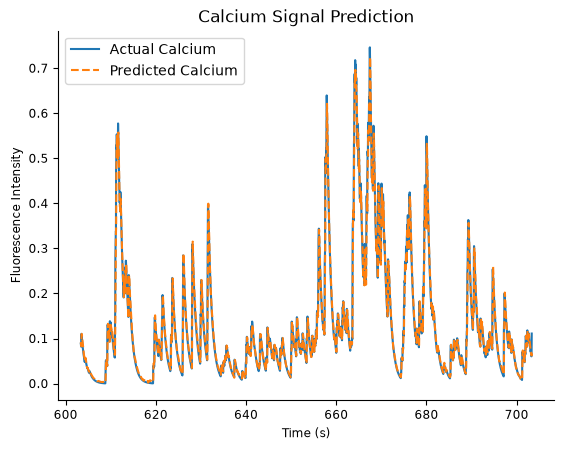

In [89]:
ep_to_plot = nap.IntervalSet(testing_ep.start[0], testing_ep.start[0] + 100)

fig = plt.figure()
plt.plot(transients.restrict(ep_to_plot)[:,0], label="Actual Calcium")
plt.plot(calcium_predicted.restrict(ep_to_plot)[:,0], '--', label="Predicted Calcium")
plt.legend()
plt.title("Calcium Signal Prediction")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity")

In [90]:
fig.savefig("../../_static/_check_figs/02-12.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-12.png)
:::
</div>

<div class="render-all">

As in Part 1, we project the coefficients back through the basis kernels to recover the coupling filters.

</div>

In [91]:
calcium_weights_dict = calcium_basis.split_by_feature(calcium_model.coef_, axis=0)
calcium_weights = calcium_weights_dict["RaisedCosineLogConv"]
_, basis_kernels = calcium_basis.evaluate_on_grid(calcium_window_size)
calcium_responses = np.einsum("jki,tk->ijt", calcium_weights, basis_kernels)
print(calcium_responses.shape)

(16, 16, 14)


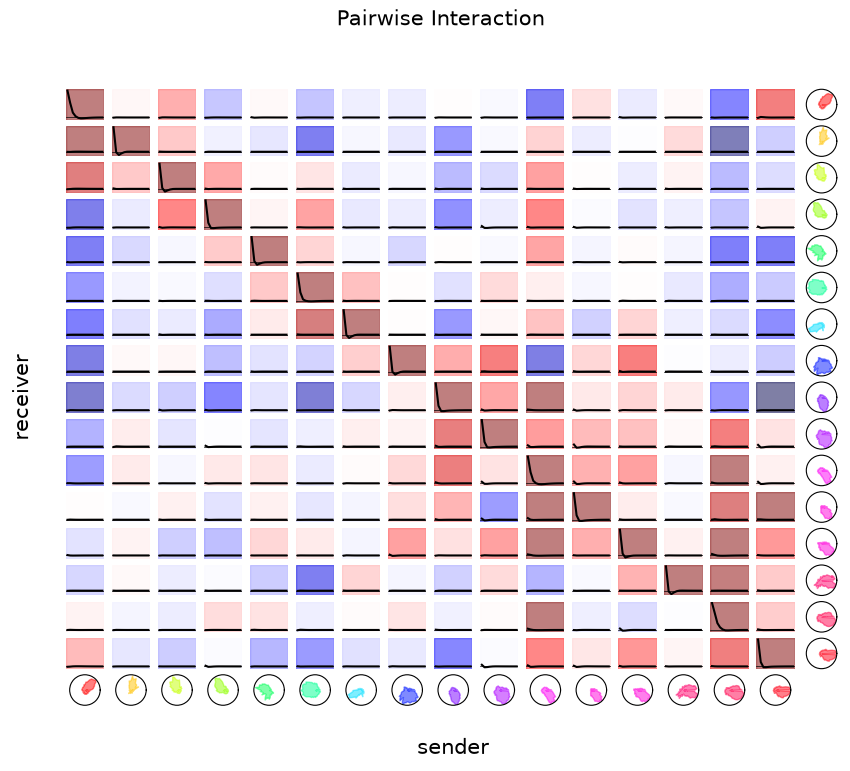

In [92]:
fig = workshop_utils.plot_coupling_filters(calcium_responses, tuning_curves)

In [93]:
fig.savefig("../../_static/_check_figs/02-13.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-13.png)
:::
</div>

<div class="render-all">

The self-coupling (diagonal) dominates because the GLM is largely fitting each neuron's own calcium decay. The slow indicator kinetics make past self-activity a very strong predictor of the current value, swamping the between-neuron interactions.

</div>

#### Fitting a population GLM with masking (no self-coupling)

<div class="render-all">

To reveal cross-neuron interactions we need to block self-connections. We do this with a binary feature mask: a matrix of ones with zeros on the diagonal. Each row of the feature matrix is multiplied element-wise by the corresponding mask row, zeroing out the self-history predictors. We then tile the mask across basis functions to match the full feature dimensionality.

</div>

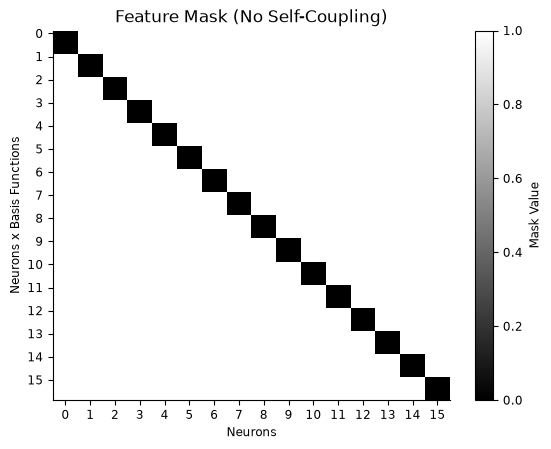

In [94]:
n_neurons = transients.shape[1]
mask = np.ones((n_neurons, n_neurons))
mask = mask - np.eye(n_neurons)
mask = np.repeat(mask, calcium_basis.n_basis_funcs, axis=0)

fig = plt.figure()
plt.imshow(mask, cmap="gray", aspect="auto", interpolation='none')
plt.xticks(ticks=np.arange(n_neurons), labels=np.arange(n_neurons))
plt.yticks(
    ticks=np.arange(0, n_neurons * calcium_basis.n_basis_funcs, calcium_basis.n_basis_funcs),
    labels=np.arange(n_neurons)
)
plt.title("Feature Mask (No Self-Coupling)")
plt.xlabel("Neurons")
plt.ylabel("Neurons x Basis Functions")
plt.colorbar(label="Mask Value")

<div class="render-all">

Now we can fit the `PopulationGLM` again using this feature mask to prevent self-coupling.

**Question: Can you re-fit `calcium_model` adding the `feature_mask` argument?**

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_model = nmo.glm.PopulationGLM(
    observation_model= , # Observation model type
    regularizer= , # Regularizer type
    solver_name= , # Solver name
    regularizer_strength= , # Regularization strength
    feature_mask= , # The feature mask to prevent self-coupling
    solver_kwargs={"maxiter": 5000}
    ).fit( , ) # Parameters are the convolved feature matrix and the calcium transients during training epoch
print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")
```
</div>

In [95]:
calcium_model = nmo.glm.PopulationGLM(
    observation_model="Gaussian",
    regularizer="Ridge",
    solver_name="LBFGS",
    regularizer_strength=0.001,
    feature_mask=mask,
    solver_kwargs={"maxiter": 5000}
    ).fit(calcium_convolved.restrict(training_ep), transients.restrict(training_ep))

print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")

Calcium model coefficients shape: (64, 16)


#### Visualizing the coupling filters without self-coupling

<div class="render-all">

With self-coupling removed, the between-neuron interactions become visible. Let's extract and plot the filters.

</div>

In [96]:
calcium_weights_dict = calcium_basis.split_by_feature(calcium_model.coef_, axis=0)
calcium_weights = calcium_weights_dict["RaisedCosineLogConv"]
_, basis_kernels = calcium_basis.evaluate_on_grid(calcium_window_size)
calcium_responses_noself = np.einsum("jki,tk->ijt", calcium_weights, basis_kernels)
print(calcium_responses_noself.shape)

(16, 16, 14)


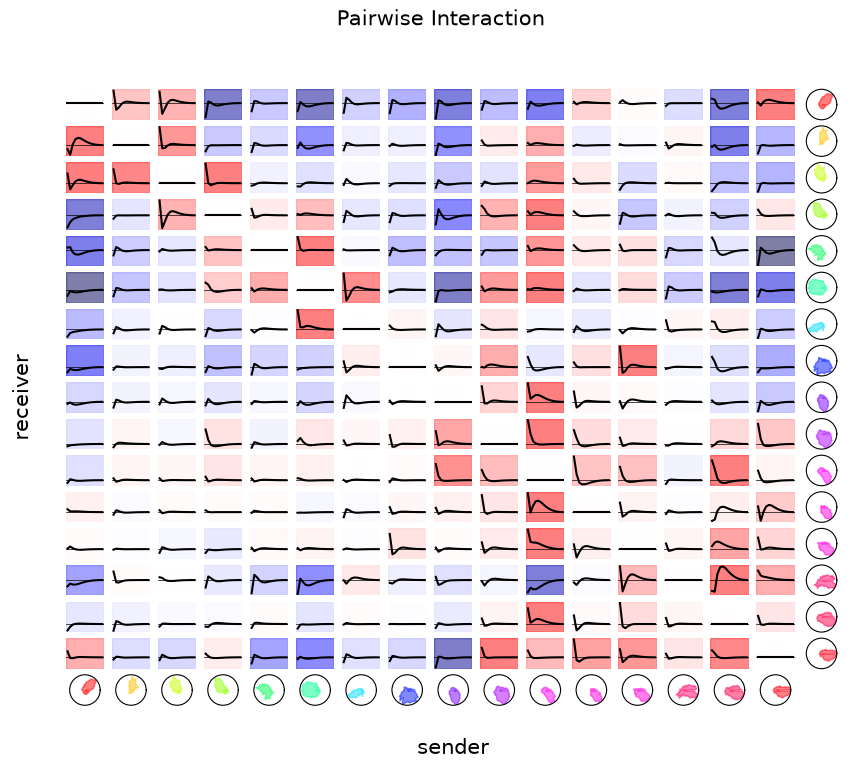

In [97]:
fig = workshop_utils.plot_coupling_filters(calcium_responses_noself, tuning_curves)

In [98]:
fig.savefig("../../_static/_check_figs/02-14.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../_static/_check_figs/02-14.png)
:::
</div>

#### Conclusion

<div class="render-all">

You have applied the same modelling framework — pynapple for data handling and nemos for GLM fitting — to two very different recording modalities. The core workflow is identical; what changes is the observation model and the basis parameterization.

**Things to explore:**
- Vary `regularizer_strength` or switch to Lasso regularization and observe how the coupling filters change.
- Add the head-direction signal as an external covariate alongside the spike history and compare the two models' predictions.
- Downsample the calcium traces with `transients.bin_average(bin_size)` and re-fit to see how temporal resolution affects the results.
- Replace `RaisedCosineLogConv` with `RaisedCosineLinearConv` and compare the filter shapes.

</div>